# Methodology: from flyby physics to the optimum-interval limit

**Private.** The pipeline behind
[`01_limit_contour.ipynb`](01_limit_contour.ipynb), one section per stage. Like
notebook 01 it is **mode-aware**: set `MODE_NUMBER` to pick the sensor mode
whose candidates and efficiency (from
[`00_efficiency_and_blips.ipynb`](00_efficiency_and_blips.ipynb)) drive the
example figures.

1. **Halo**: SHM speed distribution at the top of the atmosphere (`luhdm.halo`).
2. **Attenuation**: every trajectory is slowed through the atmosphere by the
   energy-loss ODE (`luhdm.atmosphere`); the detector-frame $f(v)$ carries the
   survival fraction.
3. **Cross section**: classical $K_1$-impulse from a finite-range Yukawa on the
   finite-size magnet (`luhdm.cross_section`; a log-space variant keeps the
   shortest ranges finite where the direct Bessels degrade at large
   $\xi = R_\text{eff}/\lambda$).
4. **Rate**: $dR/dq = \varepsilon(q)\,n_\text{DM}\int f(v)\,v\,(d\sigma/dq)\,dv$,
   assembled by **`luhdm/rate.py`** — the single module imported by the notebooks
   *and* the cluster scripts (`scripts/scan_grid.py`, `scripts/scan_lambda.py`,
   `scripts/make_maps.py`), so the two can never drift. It carries the DM-fraction
   fiducial $f_X$ = `config.F_X` and folds in the per-mode detection efficiency
   $\varepsilon(q)$ from notebook 00.
5. **Statistics**: the optimum-interval extremeness (`luhdm.limits`, wrapping the
   public `optimum_interval` package), explained below.

Fiducials (threshold $q_\text{th}$ = 0.1 TeV/$c$, exposure $T$ = 469.7 h, $f_X$,
$R_\text{eff}$) live in `luhdm/config.py`; the physics that gets tweaked lives in
`luhdm/rate.py`. Change either and the notebooks re-execute unchanged.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import atmosphere, config, cross_section, halo, limits, units

R_eff = config.R_EFF             # 200 um
Q_THRESH = config.Q_THRESH
T_TOTAL = config.T_EXPOSURE      # dataset live-time, 469.7 h (single source of truth)
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV

# the seven planned mediator ranges, largest first. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number prefix
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


RNG_SHM = np.random.default_rng(20260702)  # passed to the luhdm samplers         # luhdm samplers use legacy np.random
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

N_n = 2.51e+20   q_th = 100 GeV   R_eff = 200 um   f_X = 0.1


In [2]:
DATA = Path(f"data_mode{MODE_NUMBER}.txt")
if not DATA.exists():
    rng = np.random.default_rng(20260702)
    toy_ev = 1e9 * 10 ** rng.uniform(np.log10(Q_THRESH),
                                     np.log10(3 * Q_THRESH), size=1)
    np.savetxt(DATA, toy_ev, fmt="%.18e", header=(
        "Observed impulse candidates for the POLONAISE UHDM search.\n"
        "One impulse per line, in eV (momentum transfer q reconstructed\n"
        "from the sensor ringdown); 1 GeV = 1e9 eV.\n"
        "This file is the analysis input: edit it and rerun the notebooks."))
    print(f"wrote toy candidate to {DATA}")
EVENTS = np.atleast_1d(np.loadtxt(DATA)) / 1e9   # eV -> GeV
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [   861.     947.6   1245.8   1305.    1339.1   1348.2   1377.3   1443.1
   1461.    1478.9   1486.3   1520.7   1544.4   1615.5   1629.    1659.9
   1661.3   1678.5   1729.4   1733.5   1761.1   1795.1   1814.2   1842.3
   1872.7   2013.4   2018.3   2021.5   2033.7   2037.5   2055.5   2092.5
   2137.1   2147.5   2215.6   2245.    2366.2   2467.8   2508.7   2527.9
   2575.3   2611.2   2716.3   2842.9   2862.    2969.8   2987.9   3235.9
   3252.4   3338.4   3509.6   5705.1   6749.    6761.9   6905.1   6913.2
   6979.5   9482.1  12790.7  18563.1  18622.2  25153.3  38608.5  78392.1
 113305.8 126524.3]


## Physics model

### Cross-section handles

One handle per mediator range via `luhdm.rate.make_xsec`: Dorian's direct
tabulation for $\xi = R_\text{eff}/\lambda \le 30$, the log-space variant
beyond (the direct Bessels degrade and then underflow, $K_1(1000) = 0$ in
float64; agreement is pinned by `tests/test_cross_section_ln.py`), and
`lamb=None` for the **massless analytic limit**
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$
(`cross_section.cross_section_rutherford_projection`), used as a reference
line throughout.


In [3]:
import os
os.environ["TQDM_DISABLE"] = "1"

from luhdm import rate

XSEC = {}
for tag, lamb, color in LAMBDAS:
    t0 = time.time()
    XSEC[tag] = rate.make_xsec(lamb)
    XSEC[tag]["color"] = color
    print(f"{tag:>6}: xi = {R_eff / lamb:8.3f}  "
          f"{'log-space' if XSEC[tag]['use_ln'] else 'direct':>9}"
          f"  ({time.time() - t0:.0f}s)")
XS_MASSLESS = rate.make_xsec(None)   # analytic Rutherford projection
print("massless: analytic (no tabulation)")

  0%|          | 0/600 [00:00<?, ?it/s]

~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, 0, t_max, limit=100)
~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 3/600 [00:00<00:31, 19.19it/s]

  1%|          | 5/600 [00:00<00:31, 18.81it/s]

  1%|          | 7/600 [00:00<00:31, 18.76it/s]

  2%|▏         | 9/600 [00:00<00:31, 18.48it/s]

...

 97%|█████████▋| 584/600 [00:23<00:00, 36.20it/s]

 98%|█████████▊| 589/600 [00:23<00:00, 39.67it/s]

 99%|█████████▉| 594/600 [00:23<00:00, 42.04it/s]

100%|██████████| 600/600 [00:23<00:00, 25.39it/s]

  10um: xi =   20.000     direct  (24s)
   2um: xi =  100.000  log-space  (0s)
massless: analytic (no tabulation)


### Differential rate

$dR/dq$ (with the per-mode efficiency $\varepsilon(q)$ folded in) and the
companion flux integral (`expected_transits`, used in the Understanding section
and the appendix) come from `luhdm.rate` (in the code, `mu` is the DM mass). The
scan scripts call these exact functions, so the notebook spectra and the cached
limits share one code path.

In [4]:
v_i_samples = atmosphere.sample_shm(int(1e5), rng=RNG_SHM)  # SHM at the top of the atmosphere

# thin aliases so the cells below read like the original notebook
def differential_rate_trapz(qs, alpha_n, mu, f_v_f, xs):
    return rate.differential_rate_trapz(qs, alpha_n, mu, f_v_f, xs)

def expected_transits(alpha_n, mu, f_v_f, xs):
    return rate.expected_transits(alpha_n, mu, f_v_f, xs, T_TOTAL)

### Arrival speed distributions

What the atmosphere does to each mediator range, at the showcase point
($m_\text{DM} = 10^8$ GeV, $\alpha_n = 10^{-3}$): the detector-frame speed
distribution $f(v)$ after the energy-loss ODE, with the unattenuated standard
halo model dashed for reference. The area under each curve is the surviving
fraction. Shorter ranges scatter off air nuclei with a smaller transfer cross
section, so they arrive closer to the halo distribution; the longest ranges
are dragged hardest toward low speeds.


     range  survival fraction


       2 m              0.336


      2 cm              0.406


      2 mm              0.434


    200 µm              0.527


     20 µm              0.659


     10 µm              0.631


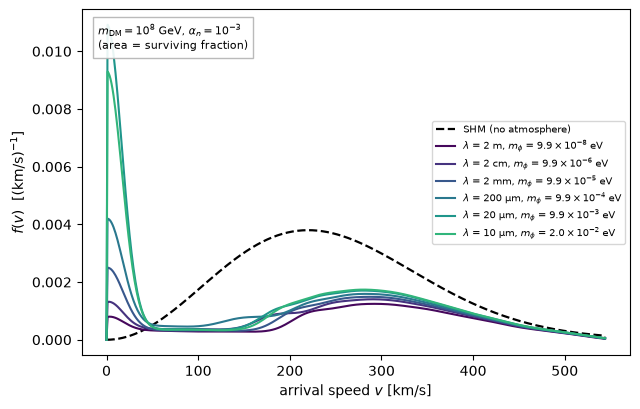

In [5]:
ALPHA_N_SHOW = 1e-3
M_SHOW = 1e8
V_MIN_SHOW = Q_THRESH / M_SHOW / 10

vs = np.linspace(V_MIN_SHOW, config.VESC, 500)
KMS = units.C_M_S / 1e3   # c -> km/s

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(vs * KMS, halo.standard_halo_model(vs) / KMS, "k--", lw=1.6,
        label="SHM (no atmosphere)")
print(f"{'range':>10} {'survival fraction':>18}")
for tag, lamb, color in LAMBDAS:
    if tag in HIDE:
        continue
    v_f_samples = atmosphere.compute_v_f_distribution(
        ALPHA_N_SHOW, lamb, M_SHOW, v_i_samples, v_min=V_MIN_SHOW, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, V_MIN_SHOW)[0]
    fv = f_v_f(vs)
    ax.plot(vs * KMS, fv / KMS, color=color, label=range_legend(lamb))
    print(f"{lamb_label(lamb).split(' = ')[-1]:>10} "
          f"{np.trapezoid(fv, vs):>18.3f}")
ax.set_xlabel(r"arrival speed $v$ [km/s]")
ax.set_ylabel(r"$f(v)$  [(km/s)$^{-1}$]")
ax.text(0.03, 0.96,
        rf"$m_{{\rm DM}} = 10^8$ GeV, $\alpha_n = 10^{{-3}}$"
        "\n(area = surviving fraction)",
        transform=ax.transAxes, ha="left", va="top", fontsize=8,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(fontsize=7, loc="center right")
fig.tight_layout()
save_figure(fig, "02_arrival_speed_distributions")

### Spectra

The attenuated $dR/dq$ for all seven ranges at a fixed mass and coupling. At
fixed coupling the spectrum weakens and steepens as the range shrinks (the
momentum cap $\tilde q < K_1(\xi)$ bites); the longest ranges sit on the
**massless analytic curve** (black dashed,
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$), with the endpoint at the halo
kinematic limit.


<>:34: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:34: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_112167/1985503427.py:34: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  "\narrival $f(v)$ computed once, at $\lambda$ = 200 µm",


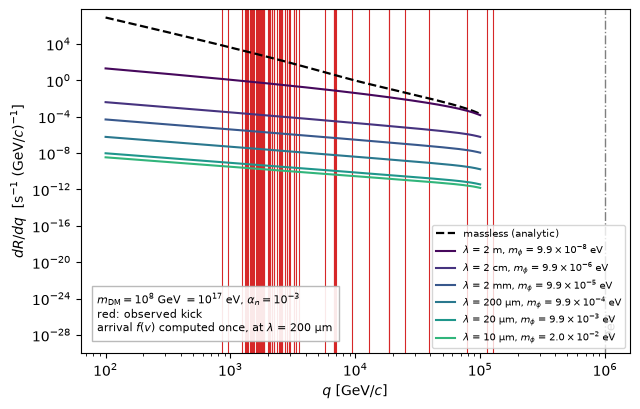

In [6]:
ALPHA_N_SHOW = 1e-3
M_SHOW = 1e8
qs_plot = np.geomspace(Q_THRESH, 1000 * Q_THRESH, 160)

v_min_show = qs_plot.min() / M_SHOW / 10
v_f_show = atmosphere.compute_v_f_distribution(
    ALPHA_N_SHOW, LAMB_REF, M_SHOW, v_i_samples, v_min=v_min_show, n_grid=80)
f_v_f_show = atmosphere.compute_f_vf(v_f_show, v_min_show)[0]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
# observed kicks first (thin, behind) so the spectra curves read on top of them
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#d62728", lw=0.8, zorder=0)
ax.loglog(qs_plot,
          differential_rate_trapz(qs_plot, ALPHA_N_SHOW, M_SHOW,
                                  f_v_f_show, XS_MASSLESS),
          color="k", ls="--", lw=1.6, label="massless (analytic)")
for tag, lamb, color in LAMBDAS:
    if tag in HIDE:
        continue
    ax.loglog(qs_plot,
              differential_rate_trapz(qs_plot, ALPHA_N_SHOW, M_SHOW,
                                      f_v_f_show, XSEC[tag]),
              color=color, label=range_legend(lamb))
ax.set_ylim(bottom=1e-30)
ax.set_xlabel(r"$q$ [GeV/$c$]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ (GeV/$c$)$^{-1}$]")
ax.axvline(1e6, color="#7f7f7f", lw=1.0, ls="-.")
ax.text(1e6, 0.03, " PeV", color="#555555", fontsize=9, ha="left",
        va="bottom", rotation=90, transform=ax.get_xaxis_transform())
ax.text(0.03, 0.05,
        rf"$m_{{\rm DM}} = 10^8$ GeV $= 10^{{17}}$ eV, $\alpha_n = 10^{{-3}}$"
        "\nred: observed kick"
        "\narrival $f(v)$ computed once, at $\lambda$ = 200 µm",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "02_spectra")

## Statistics: what the extremeness means

At each grid point the extremeness is

$$p = \Pr\big(C_\text{max}^\text{pseudo} < C_\text{max}^\text{obs}\,\big|\,m_\text{DM}, \alpha_n,\ \text{no background}\big),$$

the fraction of background-free pseudo-experiments generated *under that
hypothesis* whose most-anomalously-empty spectral stretch looks **less** empty
than the data. Physically: $p = 0.95$ means the hypothesis predicts enough
events that 95% of the time our gaps would have been filled in more than they
are: the observed emptiness sits in the 5% tail, so the point is excluded at
95% CL. The surface *is* the confidence level: the rule "exclude where
$p \ge C$" wrongly rejects a true hypothesis at most $(1-C)$ of the time
(frequentist coverage, not a posterior probability), and any CL is a level set
of the same array; the 90% contour needs no rescan. The test is one-sided by
construction: background can only *add* events, filling gaps and lowering $p$,
so backgrounds can weaken an exclusion but never fake one.


## Scan mechanics

Each cached scan (`scan7_<tag>.npz`, `scan_lambda.npz`) is a parallel sweep
over grid points; at each point: attenuation ODE → $dR/dq$ → expected count
$\mu$ and normalized spectrum shape → optimum-interval extremeness of the
observed events. Because the spectrum shape depends on the coupling being
limited (finite range, attenuation), the limit is a **level set of the
extremeness surface**, not a single $\mu$ solve. Monte-Carlo calibration
tables are shared across the plane by rounding $\mu$ onto a 2%-spaced log
grid. Runtime knobs: `n_grid`/`n_ode` (attenuation ODE resolution, the
dominant cost), `n_mc` (calibration statistics), and the grid densities; see
`FID` in the scripts.


## Appendix: validation checks

1. **$K_1$ → Coulomb convergence.** At $\lambda$ = 2 m and small coupling
   (threshold kicks come from close flybys, $b \ll \lambda$, the Coulomb
   regime), the tabulated $K_1$ machinery must reproduce the closed form
   $2\pi\alpha^2/(v^2 q^3)$. The ratios below should be $\approx 1$.
2. **Log-space vs direct.** The two shortest ranges use the log-space
   tabulation; `tests/test_cross_section_ln.py` pins agreement with Dorian's
   direct code at the percent level wherever both are healthy
   ($\xi \le 10$ across the tabulated range), and finiteness at $\xi = 1000$
   where the direct $K_1$ underflows. Run `pytest` to reproduce.
3. **Spot checks along the reference contour.** The reach $b_\text{max}$, the
   transit count $N_t$, and $\mu$ at ten points on the 95% boundary. Expect
   $N_t \ge \mu \gtrsim 3$ everywhere (exclusion is never claimed where no
   particle is expected to pass within reach) and $b_\text{max}$ far below
   the apparatus scale, so the point-sensor impulse model is safe on the
   boundary.


The spot checks below need the reference scan and its 95% contour:


In [7]:
SCANS = {}
ALL_TAGS = LAMBDAS + [("massless", None, "k")]
for tag, lamb, color in ALL_TAGS:
    f = Path(f"computation_cache/mode{MODE_NUMBER}/scan7_{tag}.npz")
    if not f.exists():
        print(f"{f} missing; skipping {tag}")
        continue
    d = np.load(f)
    assert np.allclose(d["events"], EVENTS), f"{f}: different event list!"
    if "mode" in d.files:
        assert int(d["mode"]) == MODE_NUMBER, f"{f}: cache mode {int(d['mode'])} != {MODE_NUMBER}"
    if lamb is not None:
        assert np.isclose(float(d["lamb"]), lamb), f"{f}: lambda mismatch"
    else:
        assert bool(d["massless"]), f"{f}: expected a --massless scan"
    SCANS[tag] = dict(
        ms=d["ms"], alphas_n=d["alphas_n"], extremeness=d["extremeness"],
        counts=d["counts"], n_transit=np.maximum(d["n_transit"], 0.0),
        lamb=lamb, color=color)
    # (n_transit clip: the KDE tail can oscillate slightly negative below the
    # kinematic floor)
print(f"loaded {len(SCANS)}/{len(ALL_TAGS)} scans "
      f"({len(LAMBDAS)} ranges + massless)")

REF_TAG = "200um"
if REF_TAG not in SCANS:
    # coarse inline fallback for the reference range
    ms = np.logspace(6.6, np.log10(M_PLANCK), 19)
    alphas_n = np.logspace(-8.5, 0.0, 30)
    counts = np.zeros((alphas_n.size, ms.size))
    extremeness = np.zeros((alphas_n.size, ms.size))
    N_T = np.zeros((alphas_n.size, ms.size))
    table = limits.new_table(seed=20260702)
    xs_ref = XSEC[REF_TAG]
    t0 = time.time()
    for im, m in enumerate(ms):
        for ia, alpha_n in enumerate(alphas_n):
            v_min = Q_THRESH / m / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                alpha_n, LAMB_REF, m, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            diff_rate = differential_rate_trapz(qs, alpha_n, m, f_v_f, xs_ref)
            extremeness[ia, im], counts[ia, im] = limits.extremeness_and_mu(
                table, EVENTS, qs, diff_rate, T_TOTAL)
            N_T[ia, im] = expected_transits(alpha_n, m, f_v_f, xs_ref)
    SCANS[REF_TAG] = dict(ms=ms, alphas_n=alphas_n, extremeness=extremeness,
                          counts=counts, n_transit=N_T, lamb=LAMB_REF,
                          color="#d62728")
    print(f"inline scan ({REF_TAG}): {time.time() - t0:.0f}s")

REF = SCANS[REF_TAG]

loaded 8/8 scans (7 ranges + massless)


In [8]:
# validate: K1 machinery at lambda = 2 m vs the analytic Coulomb projection.
# Coulomb regime requires b << lambda, i.e. q_tilde >> 1: pick a small coupling
# so threshold kicks come from close flybys.
xs_ml = XSEC["2m"]
alpha_chk = 1e-6 * config.N_NEUTRONS
v_chk = 1e-3
qs_chk = np.geomspace(Q_THRESH, 10 * Q_THRESH, 6)
num = rate.dsigma_dq_any(qs_chk, alpha_chk, v_chk, xs_ml)
ana = cross_section.cross_section_rutherford_projection(qs_chk, alpha_chk, v_chk)
print("K1 machinery / analytic (should be ~1):", np.round(num / ana, 4))

K1 machinery / analytic (should be ~1): [0.6736 0.8053 0.8929 0.9465 0.9826 1.0024]


In [9]:
_f, _a = plt.subplots()
cs95_ref = _a.contour(REF["ms"], REF["alphas_n"], REF["extremeness"],
                      levels=[CONFIDENCE])
plt.close(_f)

def contour_polyline(cs):
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))

poly = contour_polyline(cs95_ref)
pts = poly[~np.isnan(poly).any(axis=1)]
idx = np.linspace(0, len(pts) - 1, 10).astype(int)
xs_ref = XSEC[REF_TAG]

print(f"{'m [GeV]':>10} {'alpha_n':>9} {'max b_max [cm]':>14} {'N_transit':>10} {'mu':>7}")
for m, a in pts[idx]:
    v_min = Q_THRESH / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        a, LAMB_REF, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    alpha = a * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 300)
    b = cross_section.impact_parameter_max(Q_THRESH, alpha, LAMB_REF, R_eff, vs)
    n_transit = expected_transits(a, m, f_v_f, xs_ref)
    qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
    drdq_vals = differential_rate_trapz(qs, a, m, f_v_f, xs_ref)
    mu = np.trapezoid(drdq_vals, qs) * T_TOTAL
    print(f"{m:>10.2e} {a:>9.1e} {b.max() * 100:>14.2f} {n_transit:>10.1f} {mu:>7.2f}")
print("\nN_transit >= mu everywhere: exclusion is never claimed where fewer "
      "than ~3 particles are expected within reach.")

   m [GeV]   alpha_n max b_max [cm]  N_transit      mu


  2.71e+06   2.4e-09           0.11     3916.1 1082.30


  4.23e+07   1.5e-08           0.19      639.4  227.77


  3.81e+08   5.1e-07           0.30      220.5   91.04


  1.14e+09   1.5e-05           0.39      151.2   64.25


...

  7.33e+07   1.7e-03           0.43      804.3  246.06


  1.56e+06   3.4e-04           0.32     9347.3 1468.25


  5.09e+05   1.3e-05           0.24   310228.1 37291.38


  5.11e+05   6.2e-08           0.14    88786.6 16216.50


  2.71e+06   2.4e-09           0.11     3916.1 1082.30

N_transit >= mu everywhere: exclusion is never claimed where fewer than ~3 particles are expected within reach.
